In [ ]:
from astropy.table import Table 

# load data onto an astropy table

ceers_path = '/home/caltech-msanche3/data/ceers_cat_v1.0_final.fits'
ceers_data = Table.read(ceers_path)
# change units of flux from nJy to microJy so eazy fits correctly
for col in ceers_data.colnames:
    if '_FLUX' in col or '_FLUXERR_SE' in col:
        ceers_data[col] = ceers_data[col] * 0.001



1056


In [9]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005]
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273]
print(len(ids),len(zspec),len(ceers_zphot))

12 12 12


In [10]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = ceers_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 8
params['Z_MAX'] = 13
params['IGM_SCALE_TAU'] = 1.0

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'ceers_45k_fit_1'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/ceers_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 87345
F105W_FLUX F105W_FLUXERR_SE (202): hst/wfc3/IR/f105w.dat
F115W_FLUX F115W_FLUXERR_SE (364): jwst_nircam_f115w
F125W_FLUX F125W_FLUXERR_SE (203): hst/wfc3/IR/f125w.dat
F140W_FLUX F140W_FLUXERR_SE (204): hst/wfc3/IR/f140w.dat
F150W_FLUX F150W_FLUXERR_SE (365): jwst_nircam_f150w
F160W_FLUX F160W_FLUXERR_SE (205): hst/wfc3/IR/f160w.dat
F200W_FLUX F200W_FLUXERR_SE (366): jwst_nircam_f200w
F277W_FLUX F277W_FLUXERR_SE (375): jwst_nircam_f277w
F356W_FLUX F356W_FLUXERR_SE (376): jwst_nircam_f356w
F410M_FLUX F410M_FLUXERR_SE (383): jwst_nircam_f410m
F435W_FLUX F435W_FLUXERR_SE (233): hst/ACS_update_sep07/wfc_f435w_t81.dat
F444W_FLUX F444W_FLUXERR_SE (377): jwst_nircam_f444w
F606W_FLUX F606W_FLUXERR_SE (236): hst/ACS_update_sep07/wfc_f606w_t

100%|██████████| 6/6 [00:04<00:00,  1.49it/s]


Template   0: fsps_45k_t0.1_Av0.0.fits (NZ=1).
Template   1: fsps_45k_t0.1_Av0.5.fits (NZ=1).
Template   2: fsps_45k_t0.3_Av0.0.fits (NZ=1).
Template   3: fsps_45k_t0.3_Av0.5.fits (NZ=1).
Template   4: fsps_45k_t0.5_Av0.0.fits (NZ=1).
Template   5: fsps_45k_t0.5_Av0.5.fits (NZ=1).
Process templates: 5.970 s


45it [00:01, 32.31it/s]

Fitting program initialized successfully!


In [11]:
ez.set_sys_err(positive=True) 

chunk_size = 30000

total_obj = 0
# 2. Fit the 8<z objects
print('Fitting catalog in chunks...')
# total objects: 87345
# split into chunks
for i in range(0, 87345, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = ez.idx[i : i + chunk_size]
    sample = (8 <= ceers_data[i : i + chunk_size]['LP_Z_BEST']) & (ceers_data[i : i + chunk_size]['LP_Z_BEST'] <=13)
    ct = 0
    for j in sample:
        if j:
            ct+=1
    total_obj = total_obj + ct
    print('ct= ',ct)
    print("total= ",total_obj)
    ez.fit_catalog(chunk[sample],n_proc=16)

print('Catalog fitted successfully!')



Set sys_err = 0.03 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...
ct=  146
total=  146


100%|██████████| 45/45 [00:00<00:00, 786.65it/s]

Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=104)
Fit 0.3 s (n_proc=16, NOBJ=146)
Fitting chunk 2...
ct=  249
total=  395



100%|██████████| 45/45 [00:00<00:00, 574.79it/s]


Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=291)
Fit 0.4 s (n_proc=16, NOBJ=249)
Fitting chunk 3...
ct=  661
total=  1056


100%|██████████| 45/45 [00:00<00:00, 251.50it/s]


Compute best fits
fit_best: 0.1 s (n_proc=1,  NOBJ=740)
Fit 0.6 s (n_proc=16, NOBJ=661)
Catalog fitted successfully!


In [12]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 0.4 s (n_proc=1,  NOBJ=740)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 740/740 [00:02<00:00, 311.70it/s]
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4289: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


CALLED 45K TEMPS


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4324: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4654: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


87345
757
757
757


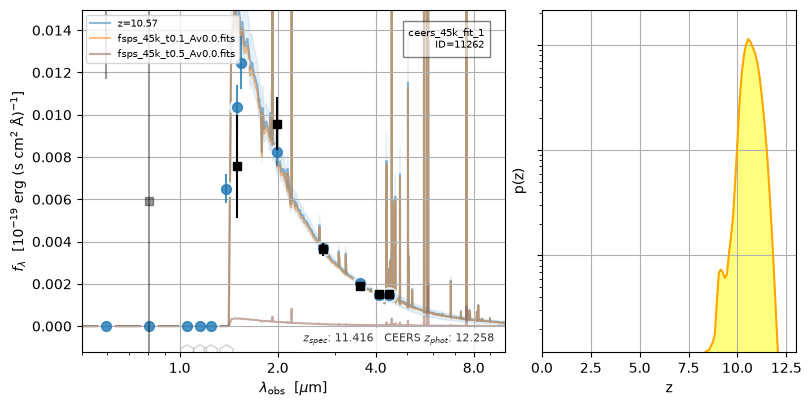

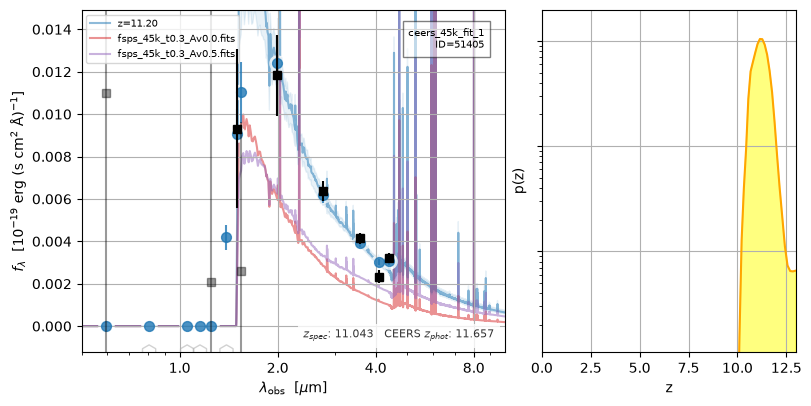

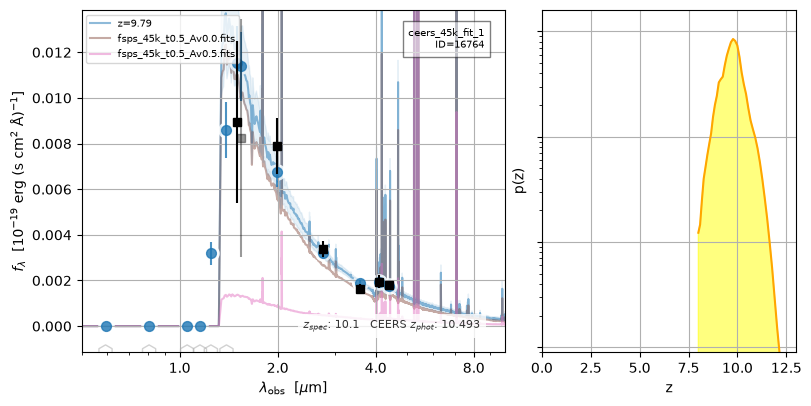

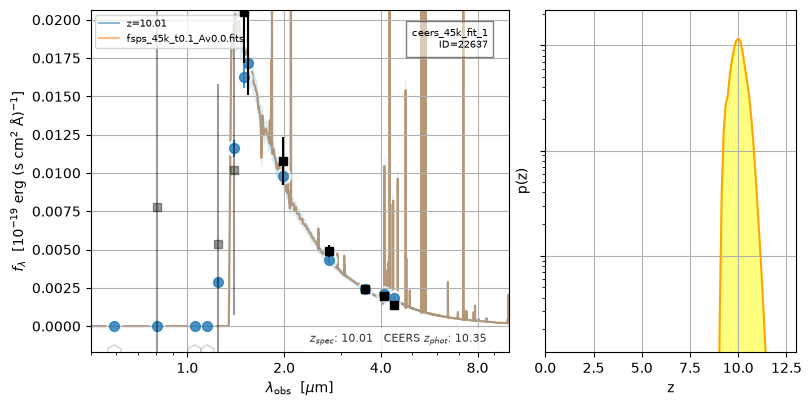

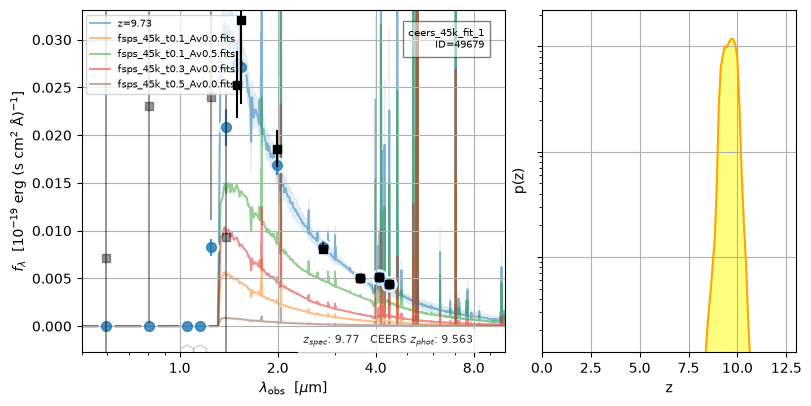

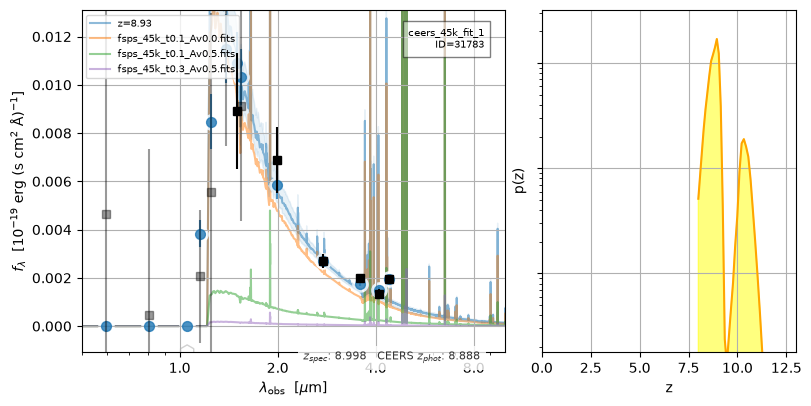

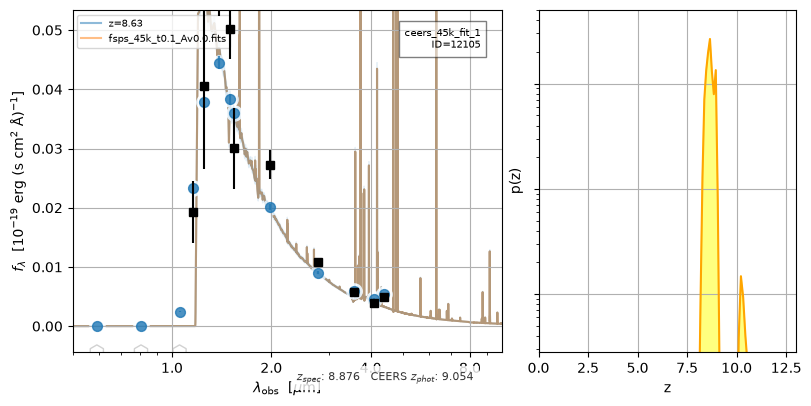

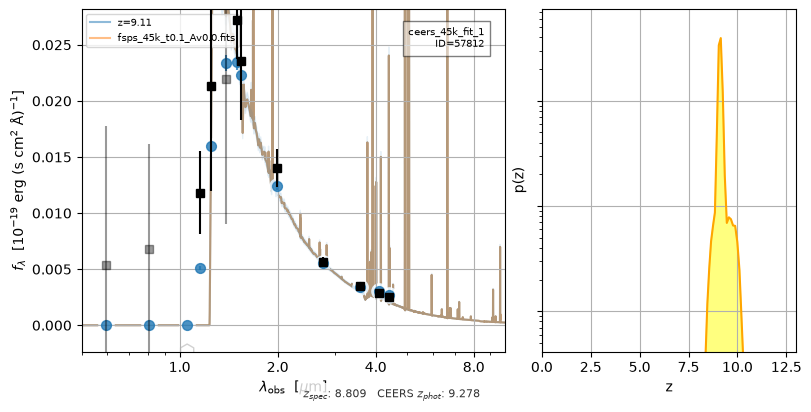

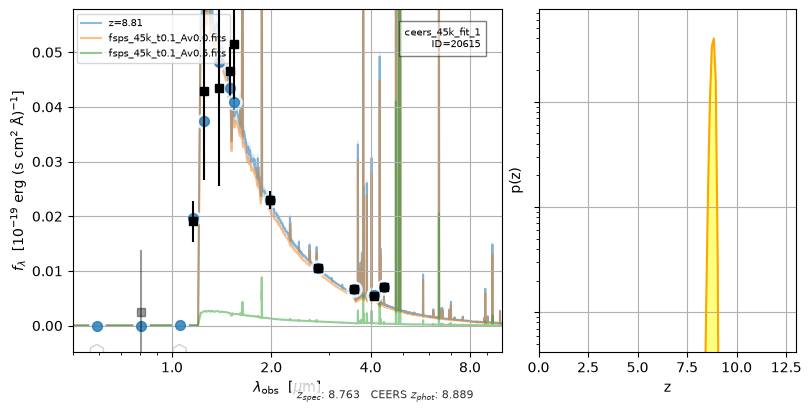

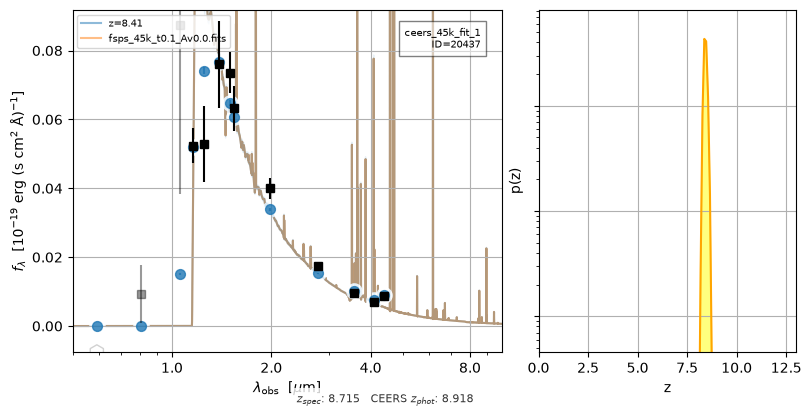

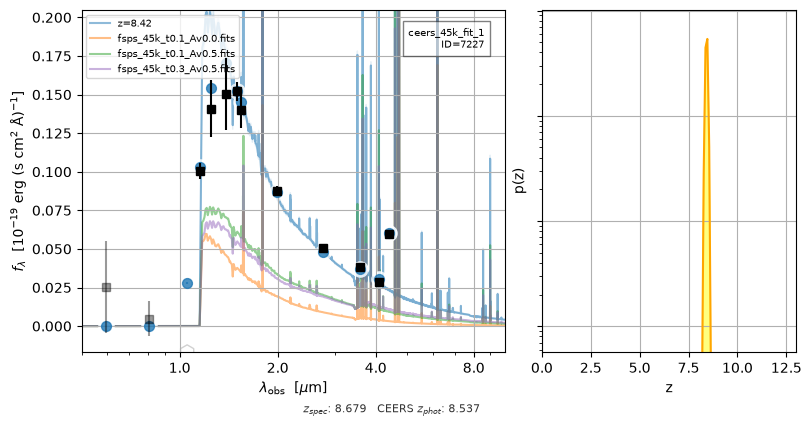

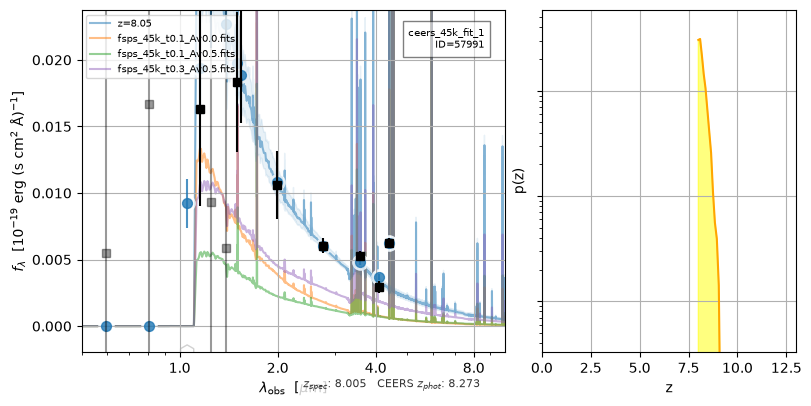

In [169]:
ids = ez.OBJID
print(len(ids))
mask1 = zout['z_phot'] > 0
zout_masked1 = zout[mask1]
ids_masked1 = ids[mask1]
print(len(ids_masked1))
print(len(zout_masked1))

output_path = '/home/caltech-msanche3/SURF2026/scripts/ceers_45k_fit_1.zout.fits'
output_data = Table.read(output_path)
output_data = output_data[mask1]
print(len(output_data))
'''
for i in range(1):
    fig, data = ez.show_fit(ids[i], xlim=[0.2, 6], show_components=True,
                              logpz=True, zr=[0,13])
'''

ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005]
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273]

# pass ID where ids[i] was previously passed
for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[0.5, 10], show_components=True,
                            logpz=True, zr=[0,13])
    # 2. Grab the current active axis
    ax = plt.gca()
    
    # 3. Add your custom text label
    # (x, y) coordinates below are relative to your data axes
    ax.text(x=-12.2, y=.0015, s=r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zphot[i]}", 
            fontsize=8,
            color='#333333',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) # Optional clean background box


/tmp/ipykernel_863299/2687762826.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=10, loc='upper right')


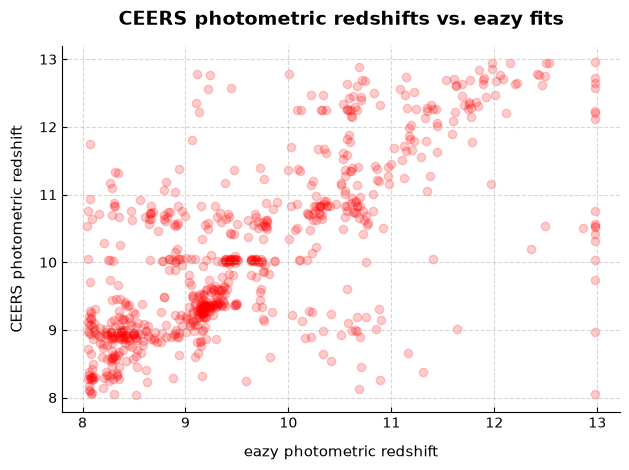

In [174]:
import matplotlib.pyplot as plt
import numpy as np
ceers_data_masked = ceers_data[mask1]




fig,ax = plt.subplots()
ax.scatter(output_data['z_phot'],ceers_data_masked['LP_Z_BEST'],alpha=.2,c='r')


    # 4. Clean up the titles and labels (use padding and font weights)
ax.set_title('CEERS photometric redshifts vs. eazy fits', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('eazy photometric redshift', fontsize=11, labelpad=10)
ax.set_ylabel('CEERS photometric redshift', fontsize=11, labelpad=10)

# 5. Make the axis tick labels look subtle
ax.tick_params(axis='both', labelsize=10,direction='in')

# 6. THE SECRET SAUCE: Subtle grid lines
# Using a very light gray, a thin width, and zorder=0 puts the grid *behind* the data lines
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)

# 7. Remove the top and right borders (spines) for an open feel
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# 8. Clean legend placement
ax.legend(frameon=False, fontsize=10, loc='upper right')

# 9. Adjust layout so nothing gets clipped
plt.tight_layout()

plt.show()


661
661


/tmp/ipykernel_769189/1546902768.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=10, loc='upper right')


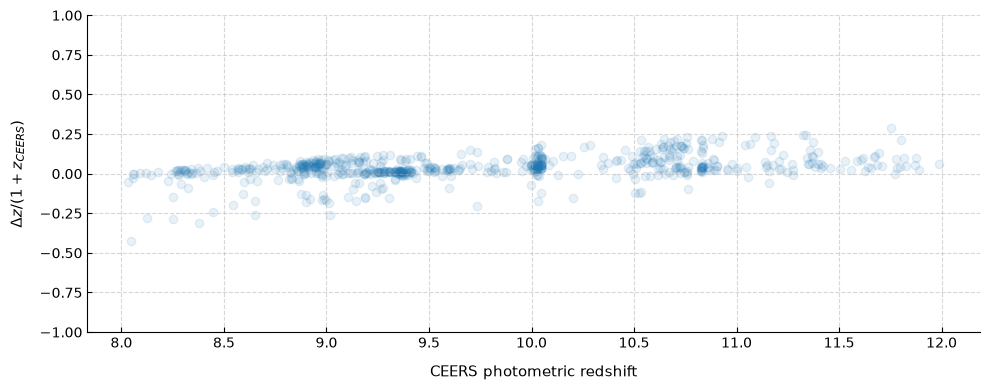

In [62]:
dz = ceers_data_masked['LP_Z_BEST'] - output_data['z_phot']
ceers_z = ceers_data_masked['LP_Z_BEST']
err = dz/(1+ceers_z)

fig,ax = plt.subplots(figsize=(10, 4))

print(len(err))
print(len(ceers_data_masked['LP_Z_BEST']))
ax.scatter(ceers_data_masked['LP_Z_BEST'],err,alpha=.1)
ax.set_ylim(-1,1)

ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)

# 7. Remove the top and right borders (spines) for an open feel
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('CEERS photometric redshift', fontsize=11, labelpad=10)
ax.set_ylabel(r'$\Delta z/(1+z_{CEERS}$)', fontsize=11, labelpad=10)

ax.legend(frameon=False, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

12 12 12
[np.float32(10.571812), np.float32(11.204756), np.float32(9.788873), np.float32(10.005748), np.float32(9.725928), np.float32(8.9344225), np.float32(8.633515), np.float32(9.108874), np.float32(8.813545), np.float32(8.411358), np.float32(8.421376), np.float32(8.0503435)]


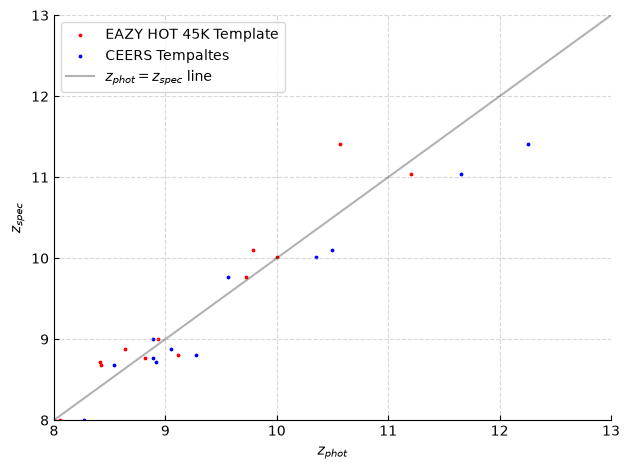

In [113]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991]
#find their index on the masked output table
ids_index = [35,168,53,84,165,105,40,204,73,72,25,206]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005]
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273]
print(len(ids),len(zspec),len(ceers_zphot))

eazy_zphot = []
for id in ids_index:
    eazy_zphot.append(output_data[id]['z_phot'])

print(eazy_zphot)

fig,ax = plt.subplots()
x = np.linspace(8,13,10)
y = np.linspace(8,13,10)
ax.scatter(eazy_zphot,zspec,c='r',s=3)
ax.scatter(ceers_zphot,zspec,c='b',s=3)
ax.plot(x,y,alpha=0.3,c='k')
ax.set_ylim(8,13)
ax.set_xlim(8,13)
ax.set_xlabel(r'$z_{phot}$')
ax.set_ylabel(r'$z_{spec}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY HOT 45K Template",'CEERS Tempaltes',r'$z_{phot} = z_{spec}$ line'])
plt.tight_layout()

Average CEERS z_phot absolute error: 2.995e-02
Average EAZY HOT 45K Templates absolute error: 2.029e-02


Text(0.5, 1.0, 'CEERS Template errors')

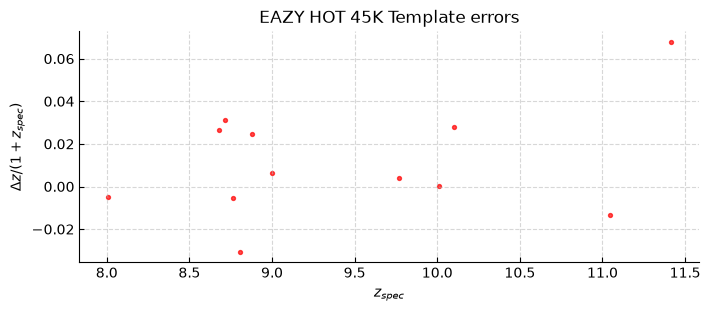

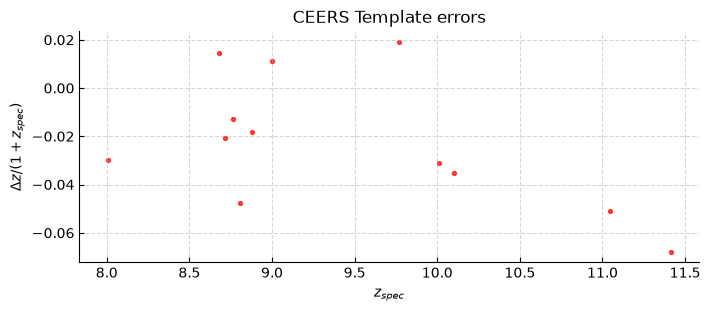

In [131]:
ceers_err = []
eazy_err = []
for i in range(12):
    ceers_err.append((zspec[i]-ceers_zphot[i])/(1+zspec[i]))
    eazy_err.append((zspec[i]-eazy_zphot[i])/(1+zspec[i]))

print(f"Average CEERS z_phot absolute error: {np.mean(np.abs(ceers_err)):.3e}")
print(f"Average EAZY HOT 45K Templates absolute error: {np.mean(np.abs(eazy_err)):.3e}")

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,eazy_err,alpha=0.7,c='r',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
ax.set_title("EAZY HOT 45K Template errors")

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,ceers_err,alpha=0.7,c='r',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
ax.set_title("CEERS Template errors")


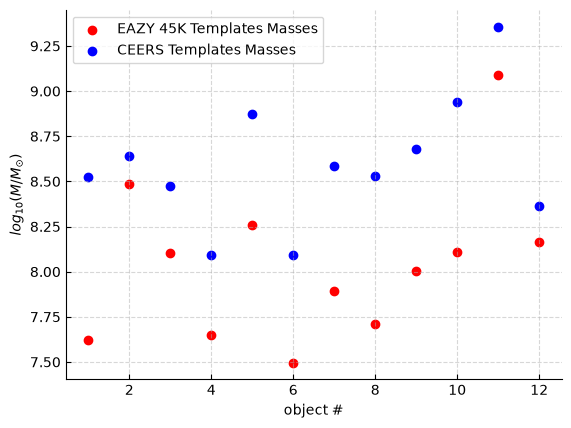

In [199]:
eazy_mass = []
ceers_mass  = []
x = np.linspace(1,12,12)
for id in ids_index:
    #print(f'eazy mass:',np.log10(output_data[id]['mass']))
    eazy_mass.append(np.log10(output_data[id]['mass']))
    #print(f'ceers mass:',ceers_data_masked[id]['LP_MASS_BEST'],"\n")
    ceers_mass.append(ceers_data_masked[id]['LP_MASS_BEST'])

fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='r')
ax.scatter(x,ceers_mass,c='b')
ax.set_xlabel('object #')
ax.set_ylabel(r'$log_{10}(M/M_{\odot})$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY 45K Templates Masses","CEERS Templates Masses"])
